# Prédiction des Charges Médicales
## Projet Machine Learning — Régression |

---

Ce notebook implémente une démarche complète de Data Science pour prédire les **charges médicales individuelles** (`charges`) à partir de caractéristiques personnelles.

### Dataset
| Variable | Type | Description |
|---|---|---|
| `age` | Numérique | Âge du bénéficiaire (18–64 ans) |
| `sex` | Catégorielle | Sexe (`female`, `male`) |
| `bmi` | Numérique | Indice de Masse Corporelle |
| `children` | Numérique | Nombre d'enfants couverts (0–5) |
| `smoker` | Catégorielle | Statut fumeur (`yes`, `no`) |
| `region` | Catégorielle | Zone géographique US |
| `charges` | Numérique | **Variable cible** — charges facturées |

### Plan du Notebook
1. Importation des librairies
2. Chargement des données
3. Analyse Exploratoire (EDA)
4. Nettoyage & Prétraitement
5. Modélisation
6. Évaluation des modèles
7. Sélection de features
8. Comparaison All Features vs Selected Features
9. Conclusion


## 2. Importation des Librairies

In [36]:
# ── Librairies standard ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Statsmodels (p-values) ────────────────────────────────────
import statsmodels.api as sm

# ── Configuration des graphiques ─────────────────────────────
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='Set2')

print("Toutes les librairies sont importées avec succès.")


Toutes les librairies sont importées avec succès.


## 3. Chargement des Données

In [37]:
# Chargement du dataset
df = pd.read_csv('medical-charges.csv')

print("=" * 50)
print(f"Shape : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print("=" * 50)

print("\n🔍 Aperçu des 5 premières lignes :")
df.head()


Shape : 1338 lignes × 7 colonnes

🔍 Aperçu des 5 premières lignes :


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [38]:
print("Aperçu des 5 dernières lignes :")
df.tail()


Aperçu des 5 dernières lignes :


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [39]:
print(" Informations sur le dataset :")
df.info()


 Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [40]:
print(" Statistiques descriptives :")
df.describe().round(2)


 Statistiques descriptives :


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [41]:
print("Types de variables :")
print(df.dtypes)


Types de variables :
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


## 4. Analyse Exploratoire des Données (EDA)

L'EDA permet de comprendre la structure du dataset, les distributions et les relations entre variables **avant toute transformation**.


### 4.1 Analyse Univariée

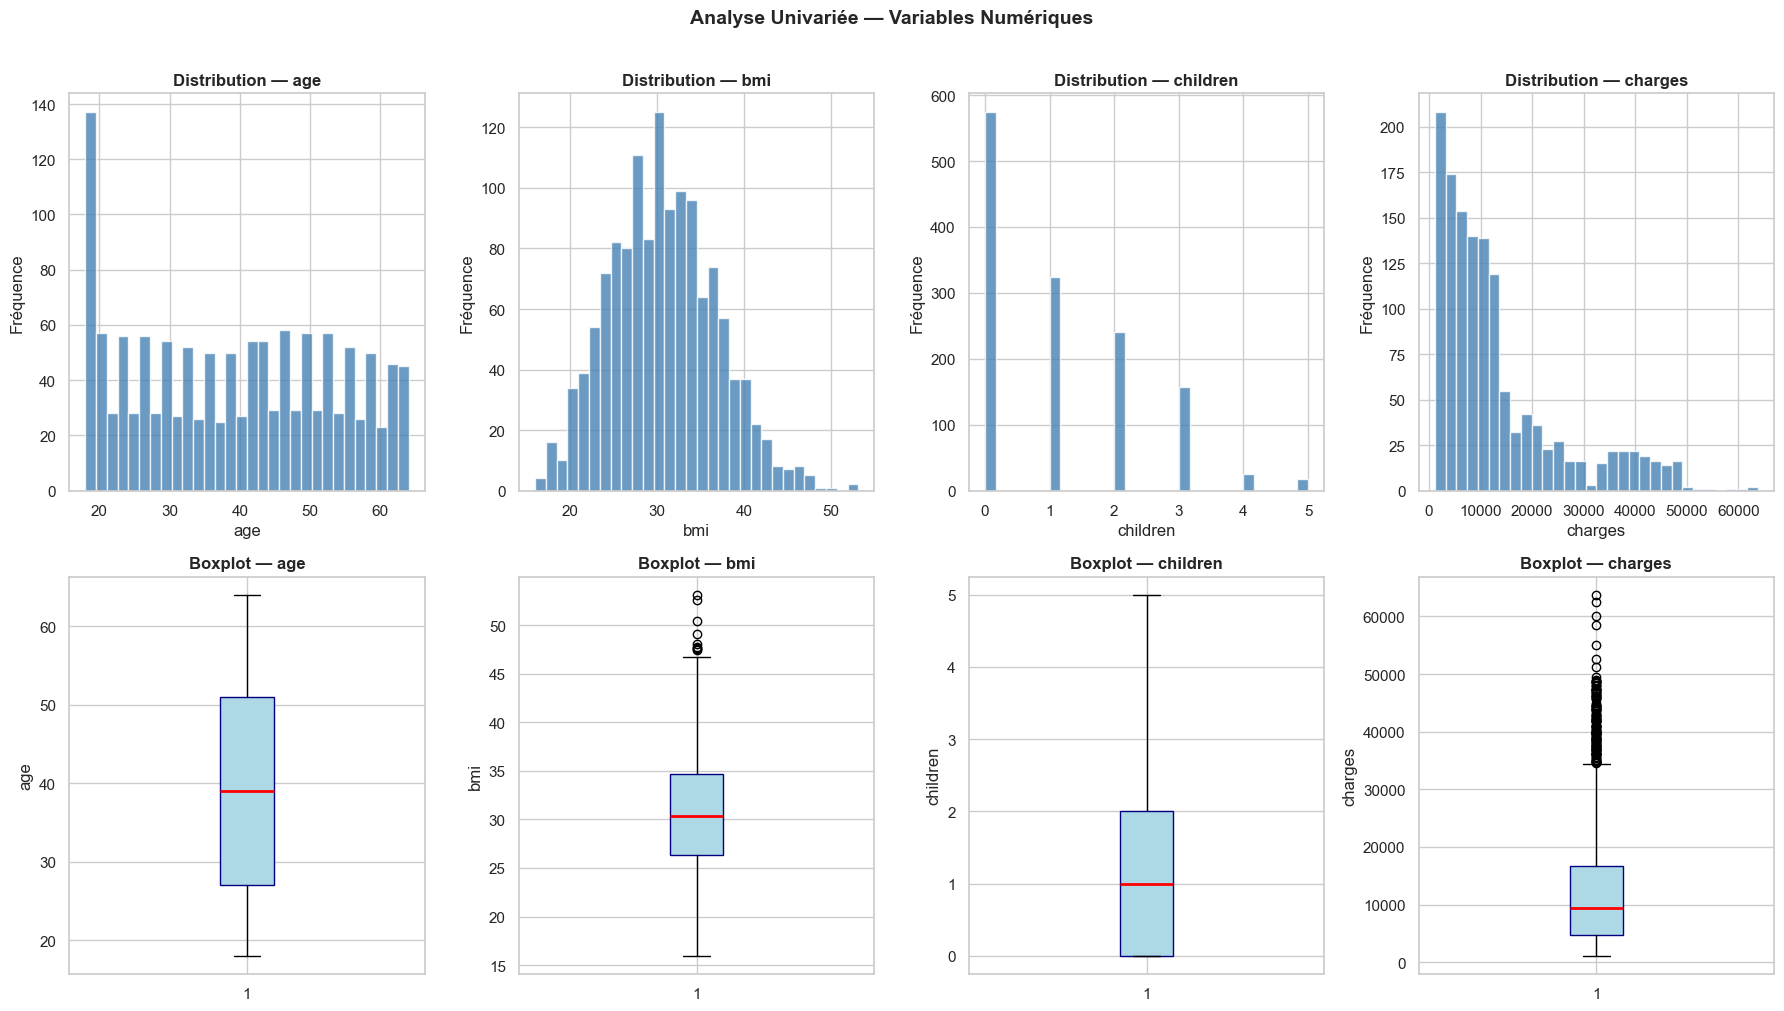

In [42]:
# ── Distribution des variables numériques ────────────────────
num_vars = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, var in enumerate(num_vars):
    # Histogramme
    axes[0, i].hist(df[var], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribution — {var}', fontweight='bold')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Fréquence')
    # Boxplot
    axes[1, i].boxplot(df[var], patch_artist=True,
                       boxprops=dict(facecolor='lightblue', color='navy'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'Boxplot — {var}', fontweight='bold')
    axes[1, i].set_ylabel(var)

plt.suptitle('Analyse Univariée — Variables Numériques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


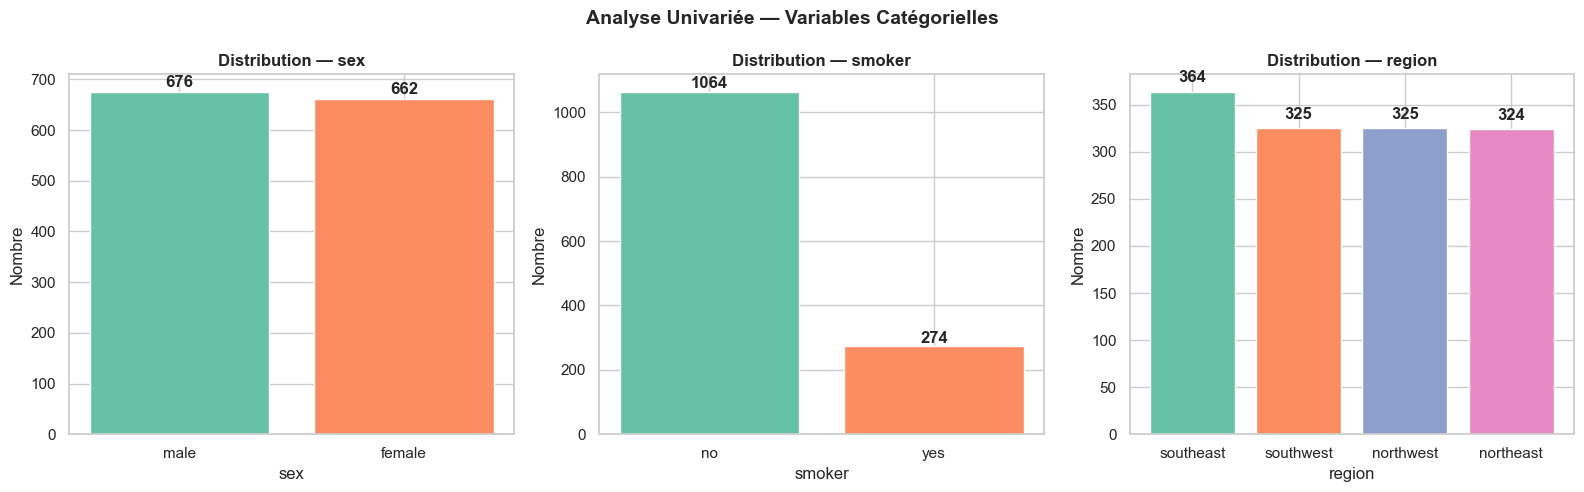


sex :
sex
male      676
female    662
Name: count, dtype: int64

smoker :
smoker
no     1064
yes     274
Name: count, dtype: int64

region :
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [43]:
# ── Comptage des variables catégorielles ─────────────────────
cat_vars = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, var in enumerate(cat_vars):
    counts = df[var].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'Distribution — {var}', fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Nombre')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 10, str(v), ha='center', fontweight='bold')

plt.suptitle('Analyse Univariée — Variables Catégorielles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé
for var in cat_vars:
    print(f"\n{var} :\n{df[var].value_counts()}")


**Observations :**
- La variable `charges` présente une distribution **asymétrique à droite** (right-skewed) avec des valeurs extrêmes élevées.
- L'âge est réparti de manière relativement uniforme entre 18 et 64 ans.
- Le BMI suit approximativement une distribution normale (autour de 30).
- ~20% des individus sont fumeurs — minorité mais potentiellement très influente.


### 4.2 Analyse Bivariée

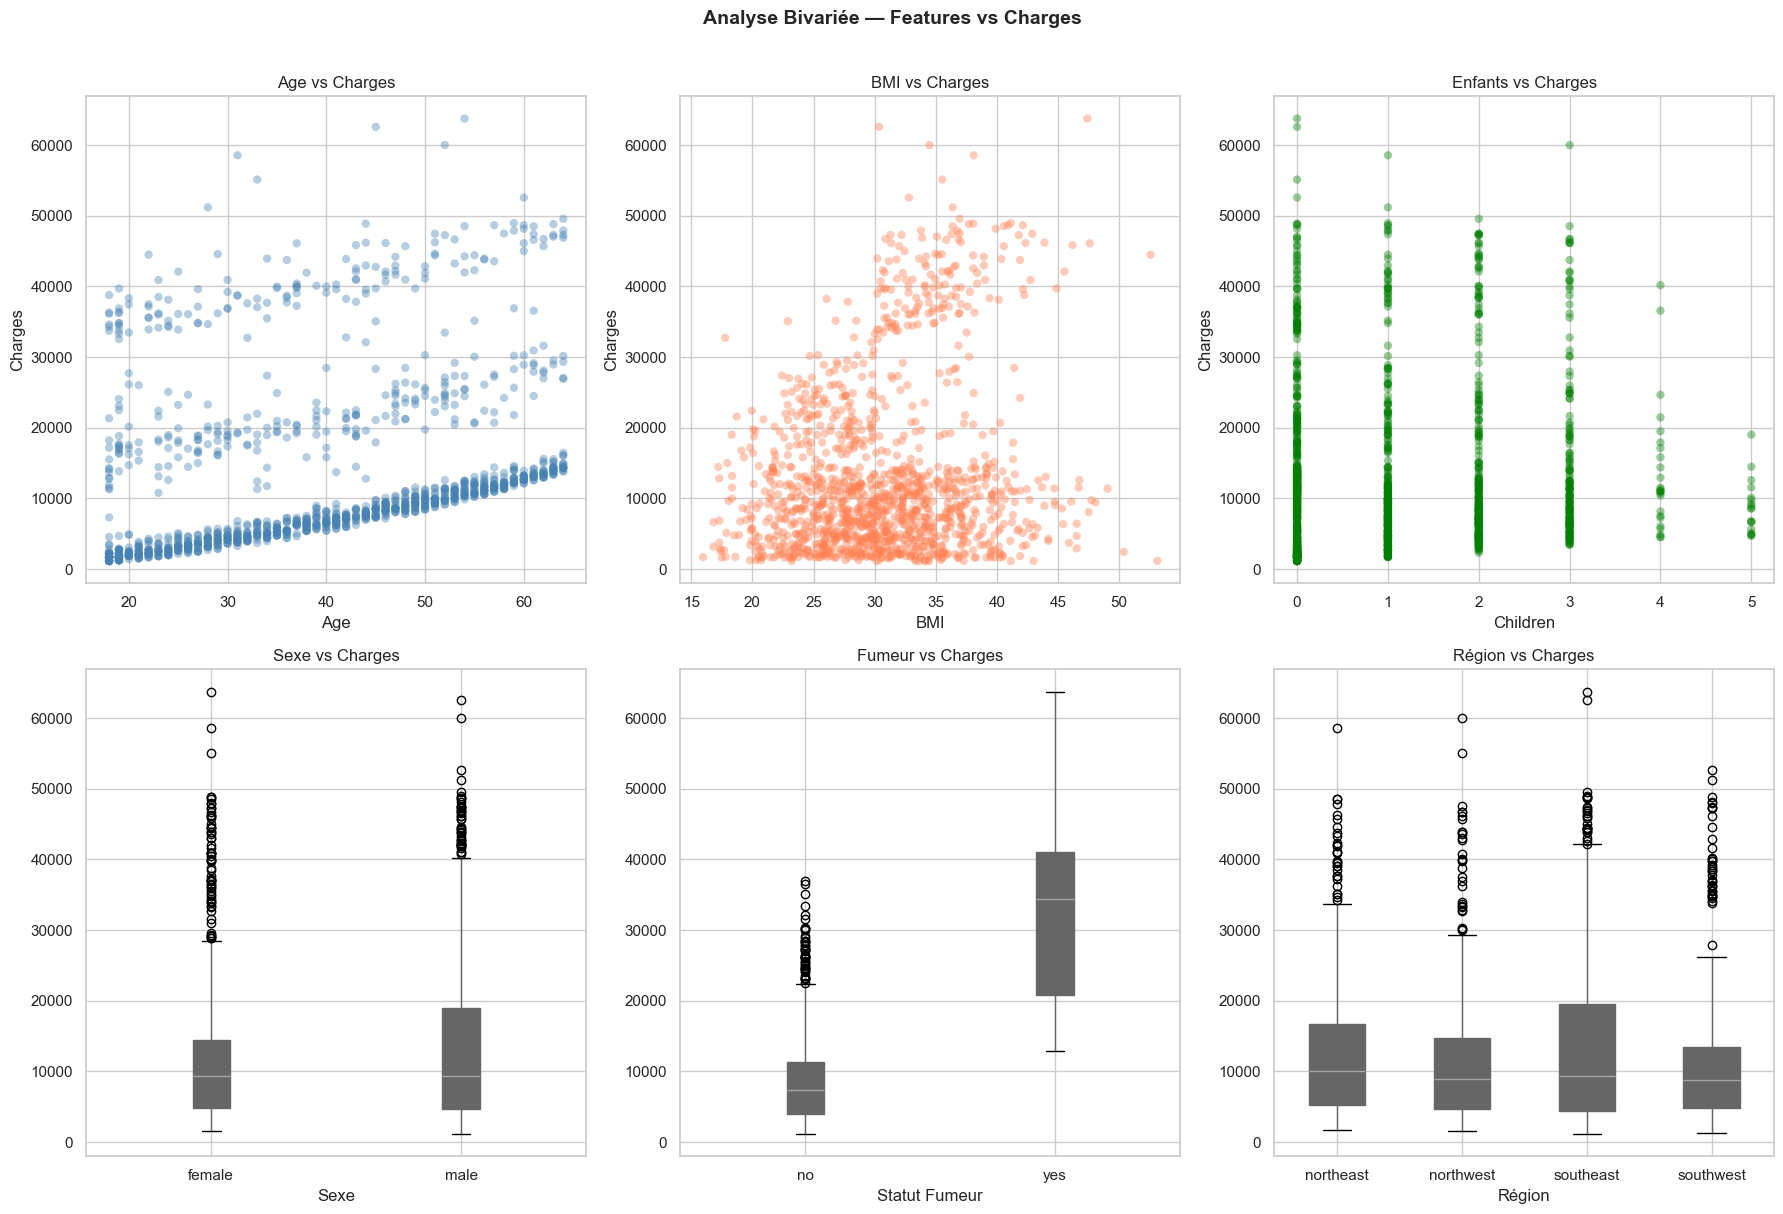

In [44]:
# ── Relation features → charges ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# age vs charges
axes[0,0].scatter(df['age'], df['charges'], alpha=0.4, c='steelblue', edgecolors='none')
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Charges')
axes[0,0].set_title('Age vs Charges')

# bmi vs charges
axes[0,1].scatter(df['bmi'], df['charges'], alpha=0.4, c='coral', edgecolors='none')
axes[0,1].set_xlabel('BMI'); axes[0,1].set_ylabel('Charges')
axes[0,1].set_title('BMI vs Charges')

# children vs charges
axes[0,2].scatter(df['children'], df['charges'], alpha=0.4, c='green', edgecolors='none')
axes[0,2].set_xlabel('Children'); axes[0,2].set_ylabel('Charges')
axes[0,2].set_title('Enfants vs Charges')

# sex vs charges
df.boxplot(column='charges', by='sex', ax=axes[1,0], patch_artist=True)
axes[1,0].set_title('Sexe vs Charges'); axes[1,0].set_xlabel('Sexe')

# smoker vs charges
df.boxplot(column='charges', by='smoker', ax=axes[1,1], patch_artist=True)
axes[1,1].set_title('Fumeur vs Charges'); axes[1,1].set_xlabel('Statut Fumeur')

# region vs charges
df.boxplot(column='charges', by='region', ax=axes[1,2], patch_artist=True)
axes[1,2].set_title('Région vs Charges'); axes[1,2].set_xlabel('Région')

plt.suptitle('', fontsize=1)
fig.suptitle('Analyse Bivariée — Features vs Charges', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


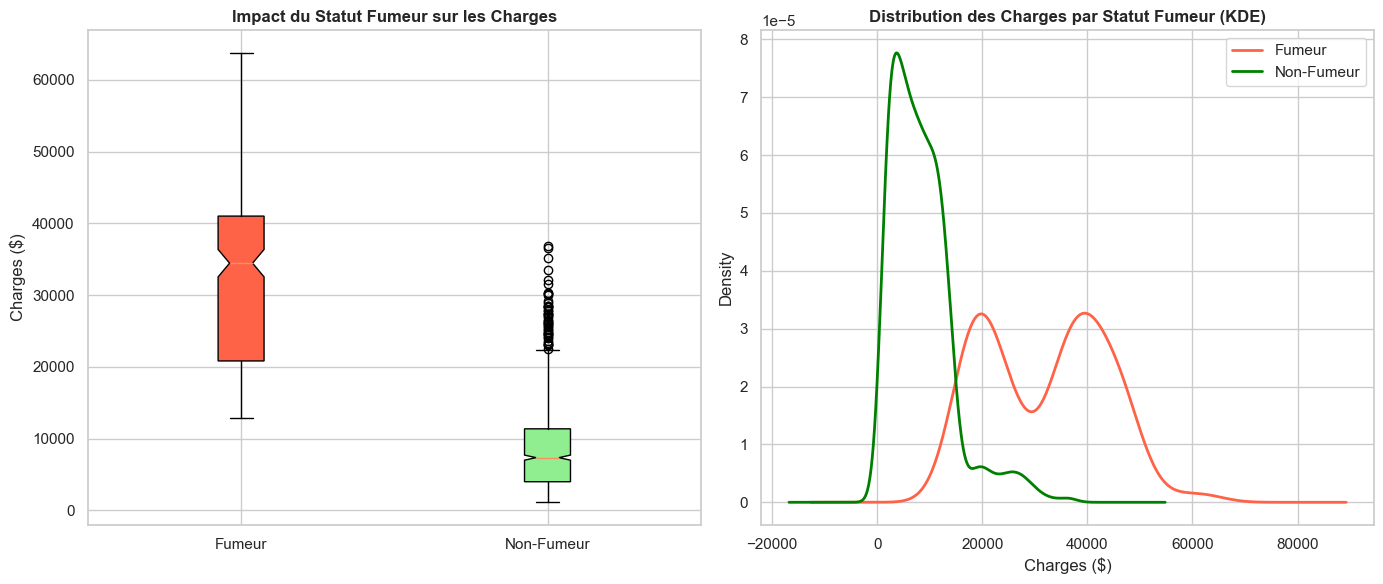

Statistiques par statut fumeur :
         count      mean       std       min       25%       50%       75%  \
smoker                                                                       
no      1064.0   8434.27   5993.78   1121.87   3986.44   7345.41  11362.89   
yes      274.0  32050.23  11541.55  12829.46  20826.24  34456.35  41019.21   

             max  
smoker            
no      36910.61  
yes     63770.43  


In [45]:
# ── Impact du statut fumeur ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot charges by smoker
smoker_groups = [df[df['smoker']=='yes']['charges'].values,
                 df[df['smoker']=='no']['charges'].values]
bp = axes[0].boxplot(smoker_groups, labels=['Fumeur', 'Non-Fumeur'],
                     patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('tomato')
bp['boxes'][1].set_facecolor('lightgreen')
axes[0].set_title('Impact du Statut Fumeur sur les Charges', fontweight='bold')
axes[0].set_ylabel('Charges ($)')

# KDE plot
df[df['smoker']=='yes']['charges'].plot.kde(ax=axes[1], label='Fumeur', color='tomato', linewidth=2)
df[df['smoker']=='no']['charges'].plot.kde(ax=axes[1], label='Non-Fumeur', color='green', linewidth=2)
axes[1].set_title('Distribution des Charges par Statut Fumeur (KDE)', fontweight='bold')
axes[1].set_xlabel('Charges ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Statistiques par statut fumeur :")
print(df.groupby('smoker')['charges'].describe().round(2))


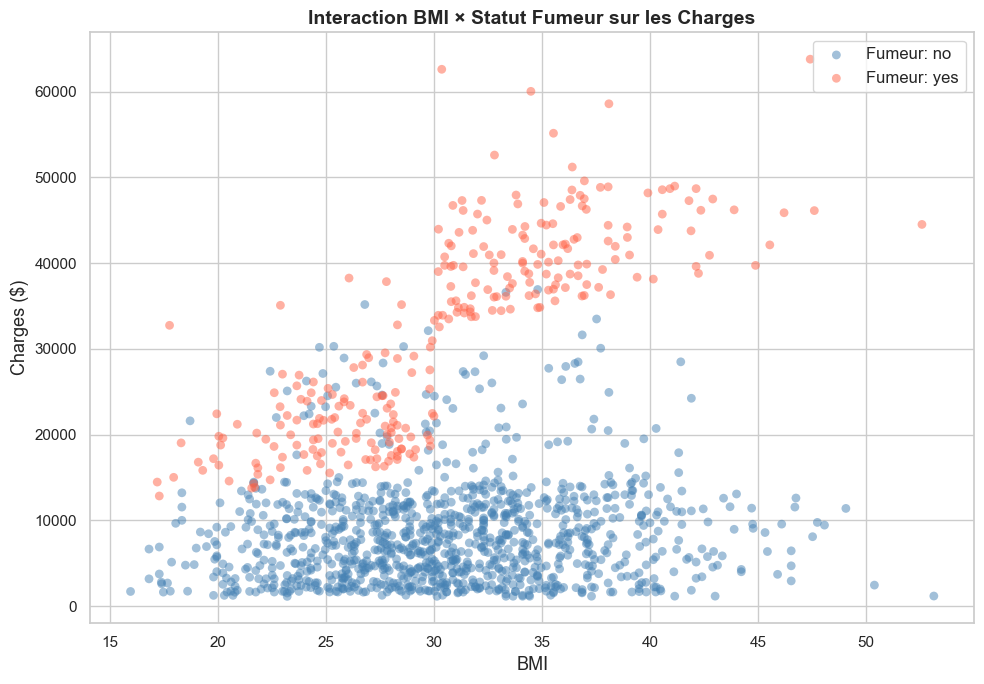

In [46]:
# ── Interaction BMI × Smoker sur les charges ─────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = {'yes': 'tomato', 'no': 'steelblue'}
for smoker_val, group in df.groupby('smoker'):
    ax.scatter(group['bmi'], group['charges'],
               c=colors[smoker_val], label=f'Fumeur: {smoker_val}',
               alpha=0.5, edgecolors='none', s=40)

ax.set_xlabel('BMI', fontsize=13)
ax.set_ylabel('Charges ($)', fontsize=13)
ax.set_title('Interaction BMI × Statut Fumeur sur les Charges', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


**Observations clés :**
- Le statut **fumeur** est de loin le facteur le plus discriminant : les fumeurs paient en moyenne **3–4x plus** cher.
- Pour les fumeurs, un **BMI élevé** amplifie encore davantage les charges (effet multiplicatif).
- L'âge montre une corrélation positive avec les charges, mais avec une forte dispersion.


### 4.3 Analyse Multivariée

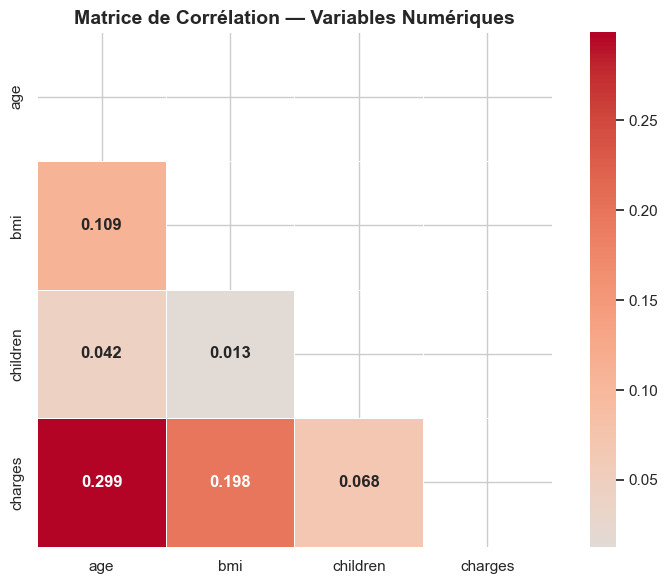


Correlations avec 'charges' :
charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998


In [47]:
# ── Matrice de corrélation ────────────────────────────────────
num_df = df[['age', 'bmi', 'children', 'charges']]
corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, mask=mask, ax=ax,
            square=True, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Matrice de Corrélation — Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelations avec 'charges' :")
print(corr_matrix['charges'].sort_values(ascending=False).to_string())


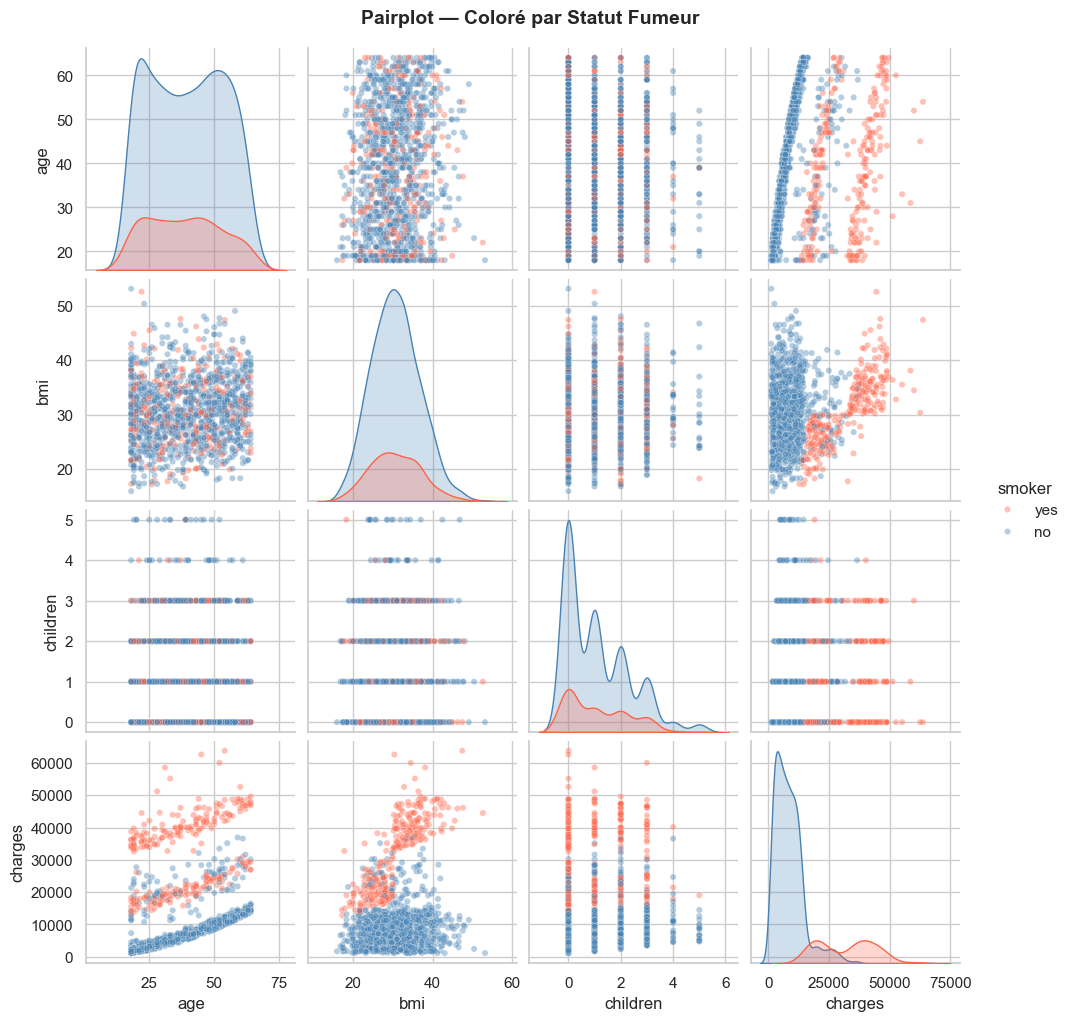

In [48]:
# ── Pairplot coloré par smoker ────────────────────────────────
pairplot_df = df[['age', 'bmi', 'children', 'charges', 'smoker']]
g = sns.pairplot(pairplot_df, hue='smoker', palette={'yes': 'tomato', 'no': 'steelblue'},
                 plot_kws={'alpha': 0.4, 's': 20}, diag_kind='kde')
g.fig.suptitle('Pairplot — Coloré par Statut Fumeur', y=1.02, fontsize=14, fontweight='bold')
plt.show()


### 4.4 Détection des Outliers (Méthode IQR)

Résumé des Outliers (méthode IQR) :
Variable      Q1       Q3      IQR  Borne Inf.  Borne Sup.  Nb Outliers  % Outliers
     age   27.00    51.00    24.00       -9.00       87.00            0        0.00
     bmi   26.30    34.69     8.40       13.70       47.29            9        0.67
children    0.00     2.00     2.00       -3.00        5.00            0        0.00
 charges 4740.29 16639.91 11899.63   -13109.15    34489.35          139       10.39


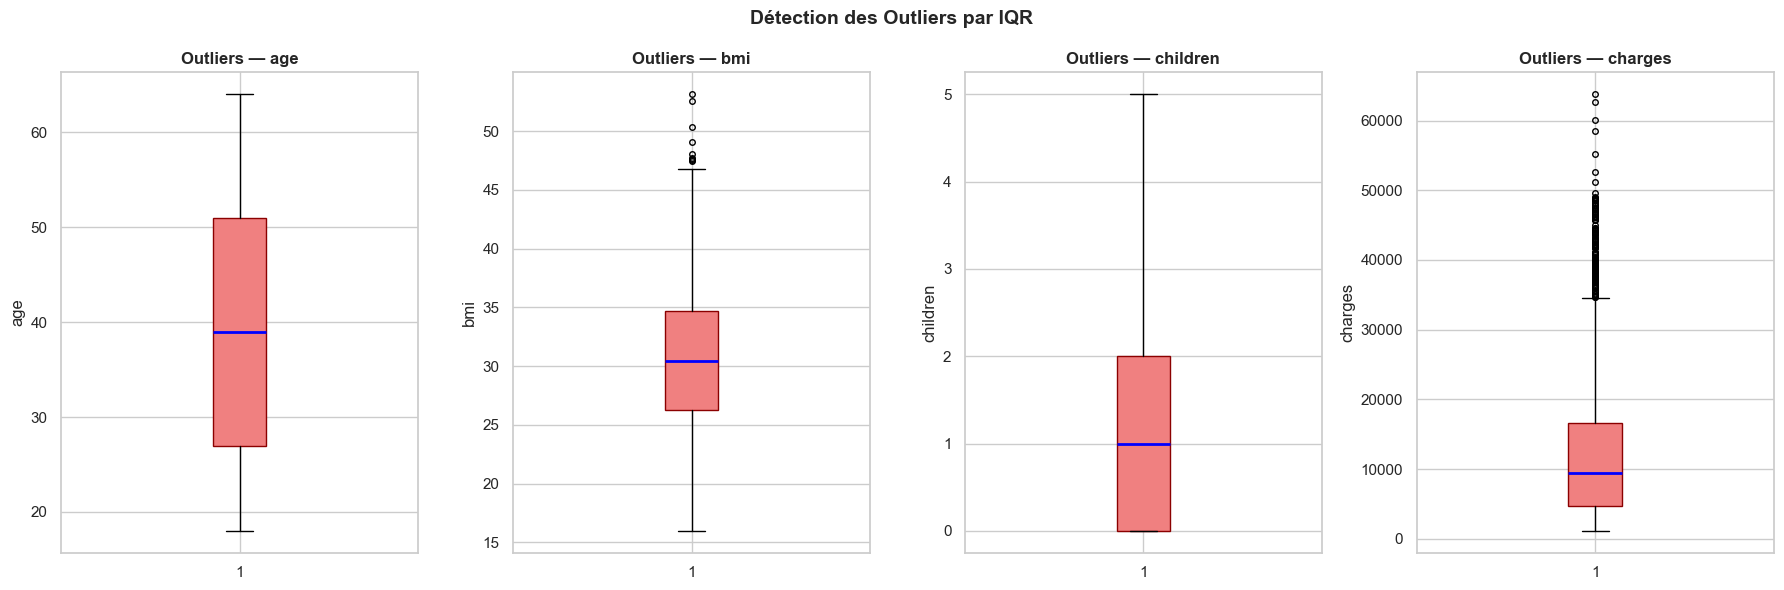

In [49]:
# ── Détection outliers par IQR ───────────────────────────────
num_vars = ['age', 'bmi', 'children', 'charges']
outlier_summary = []

for var in num_vars:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[var] < lower) | (df[var] > upper)]
    outlier_summary.append({
        'Variable': var,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Borne Inf.': round(lower, 2),
        'Borne Sup.': round(upper, 2),
        'Nb Outliers': len(outliers),
        '% Outliers': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("Résumé des Outliers (méthode IQR) :")
print(outlier_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for i, var in enumerate(num_vars):
    axes[i].boxplot(df[var], patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='blue', linewidth=2),
                    flierprops=dict(marker='o', color='red', markersize=4))
    axes[i].set_title(f'Outliers — {var}', fontweight='bold')
    axes[i].set_ylabel(var)

plt.suptitle('Détection des Outliers par IQR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Nettoyage et Prétraitement

### 5.1 Valeurs Manquantes

In [50]:
# ── Vérification des valeurs manquantes ──────────────────────
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing)
print(f"\nTotal valeurs manquantes : {missing.sum()}")

if missing.sum() == 0:
    print("\n Aucune valeur manquante — aucune imputation nécessaire.")


Valeurs manquantes par colonne :
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total valeurs manquantes : 0

 Aucune valeur manquante — aucune imputation nécessaire.


### 5.2 Doublons

In [51]:
# ── Vérification et suppression des doublons ─────────────────
n_dup = df.duplicated().sum()
print(f"Nombre de doublons détectés : {n_dup}")

if n_dup > 0:
    df = df.drop_duplicates()
    print(f"{n_dup} doublons supprimés. Nouveau shape : {df.shape}")
else:
    print("Aucun doublon détecté.")

print(f"\nDataset final : {df.shape[0]} observations × {df.shape[1]} colonnes")


Nombre de doublons détectés : 1
1 doublons supprimés. Nouveau shape : (1337, 7)

Dataset final : 1337 observations × 7 colonnes


### 5.3 Encodage des Variables Catégorielles

**Stratégie d'encodage :**
- `smoker` → **Label Encoding** (0/1) : variable binaire ordinale naturelle, très impactante.
- `sex` → **Label Encoding** (0/1) : variable binaire.
- `region` → **One-Hot Encoding** : 4 modalités sans ordre naturel — évite d'introduire une fausse ordinalité.


In [52]:
# ── Copie du dataset pour prétraitement ──────────────────────
df_processed = df.copy()

# Label Encoding : smoker (yes=1, no=0) et sex (female=0, male=1)
le = LabelEncoder()
df_processed['smoker'] = le.fit_transform(df_processed['smoker'])   # yes=1, no=0
df_processed['sex']    = le.fit_transform(df_processed['sex'])       # female=0, male=1

# One-Hot Encoding : region
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=True)
# Convertir les colonnes booléennes en int (compatibilité statsmodels)
bool_cols = df_processed.select_dtypes(include='bool').columns
df_processed[bool_cols] = df_processed[bool_cols].astype(int)

print("Encodage effectué.")
print(f"\nShape après encodage : {df_processed.shape}")
print("\nColonnes disponibles :")
print(df_processed.columns.tolist())
df_processed.head()


Encodage effectué.

Shape après encodage : (1337, 9)

Colonnes disponibles :
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


### 5.4 Feature Scaling

On applique un `StandardScaler` sur les variables numériques continues (`age`, `bmi`, `children`).

> **Note** : La variable cible `charges` n'est **pas** standardisée — on veut garder les prédictions dans leur unité d'origine ($).


In [53]:
# ── Séparation X / y ─────────────────────────────────────────
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nFeatures : {X.columns.tolist()}")


X shape : (1337, 8)
y shape : (1337,)

Features : ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


### 5.5 Train / Test Split

In [54]:
# ── Split 80% / 20% ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Split effectué avec random_state=42")
print(f"   Train : {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test  : {X_test.shape[0]} observations  ({X_test.shape[0]/len(X)*100:.1f}%)")

# ── Scaling uniquement sur les colonnes numériques continues ──
num_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

print("\n StandardScaler appliqué sur :", num_cols)
print("\nAperçu X_train après scaling :")
X_train_scaled.head()


Split effectué avec random_state=42
   Train : 1069 observations (80.0%)
   Test  : 268 observations  (20.0%)

 StandardScaler appliqué sur : ['age', 'bmi', 'children']

Aperçu X_train après scaling :


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
1114,-1.157680,1,-0.996928,-0.907908,0,0,0,0
968,-1.300619,1,-0.792762,0.766904,0,0,0,0
599,0.914926,0,1.154664,0.766904,0,1,0,0
170,1.701087,1,1.806837,-0.907908,0,0,1,0
275,0.557580,0,-0.651417,0.766904,0,0,0,0


## 6. Modélisation

On entraîne **4 modèles de régression** :
1. **Linear Regression** (OLS)
2. **Ridge** (régularisation L2)
3. **Lasso** (régularisation L1)
4. **ElasticNet** (L1 + L2)


### 6.1 Entraînement des Modèles

In [55]:
# ── Définition des modèles ────────────────────────────────────
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=1.0, max_iter=10000),
    'ElasticNet':        ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

# ── Entraînement et prédictions ───────────────────────────────
predictions = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)
    print(f" {name} entraîné.")

print("\n Tous les modèles ont été entraînés.")


 Linear Regression entraîné.
 Ridge entraîné.
 Lasso entraîné.
 ElasticNet entraîné.

 Tous les modèles ont été entraînés.


### 6.2 Coefficients des Modèles

Coefficients des modèles :
                  Linear Regression       Ridge       Lasso  ElasticNet
Feature                                                                
age                       3472.9756   3468.3867   3472.3345   2203.1792
sex                       -101.5421    -91.8269    -96.8023    354.3677
bmi                       1927.8283   1923.1746   1925.4588   1206.2311
children                   636.5012    637.3336    635.6337    563.4961
smoker                   23077.7646  22940.7934  23070.9909   5530.8168
region_northwest          -391.7615   -389.1091   -374.9408   -247.6199
region_southeast          -838.9196   -819.8175   -820.4098    266.5113
region_southwest          -659.1398   -652.6784   -641.8073   -215.8067


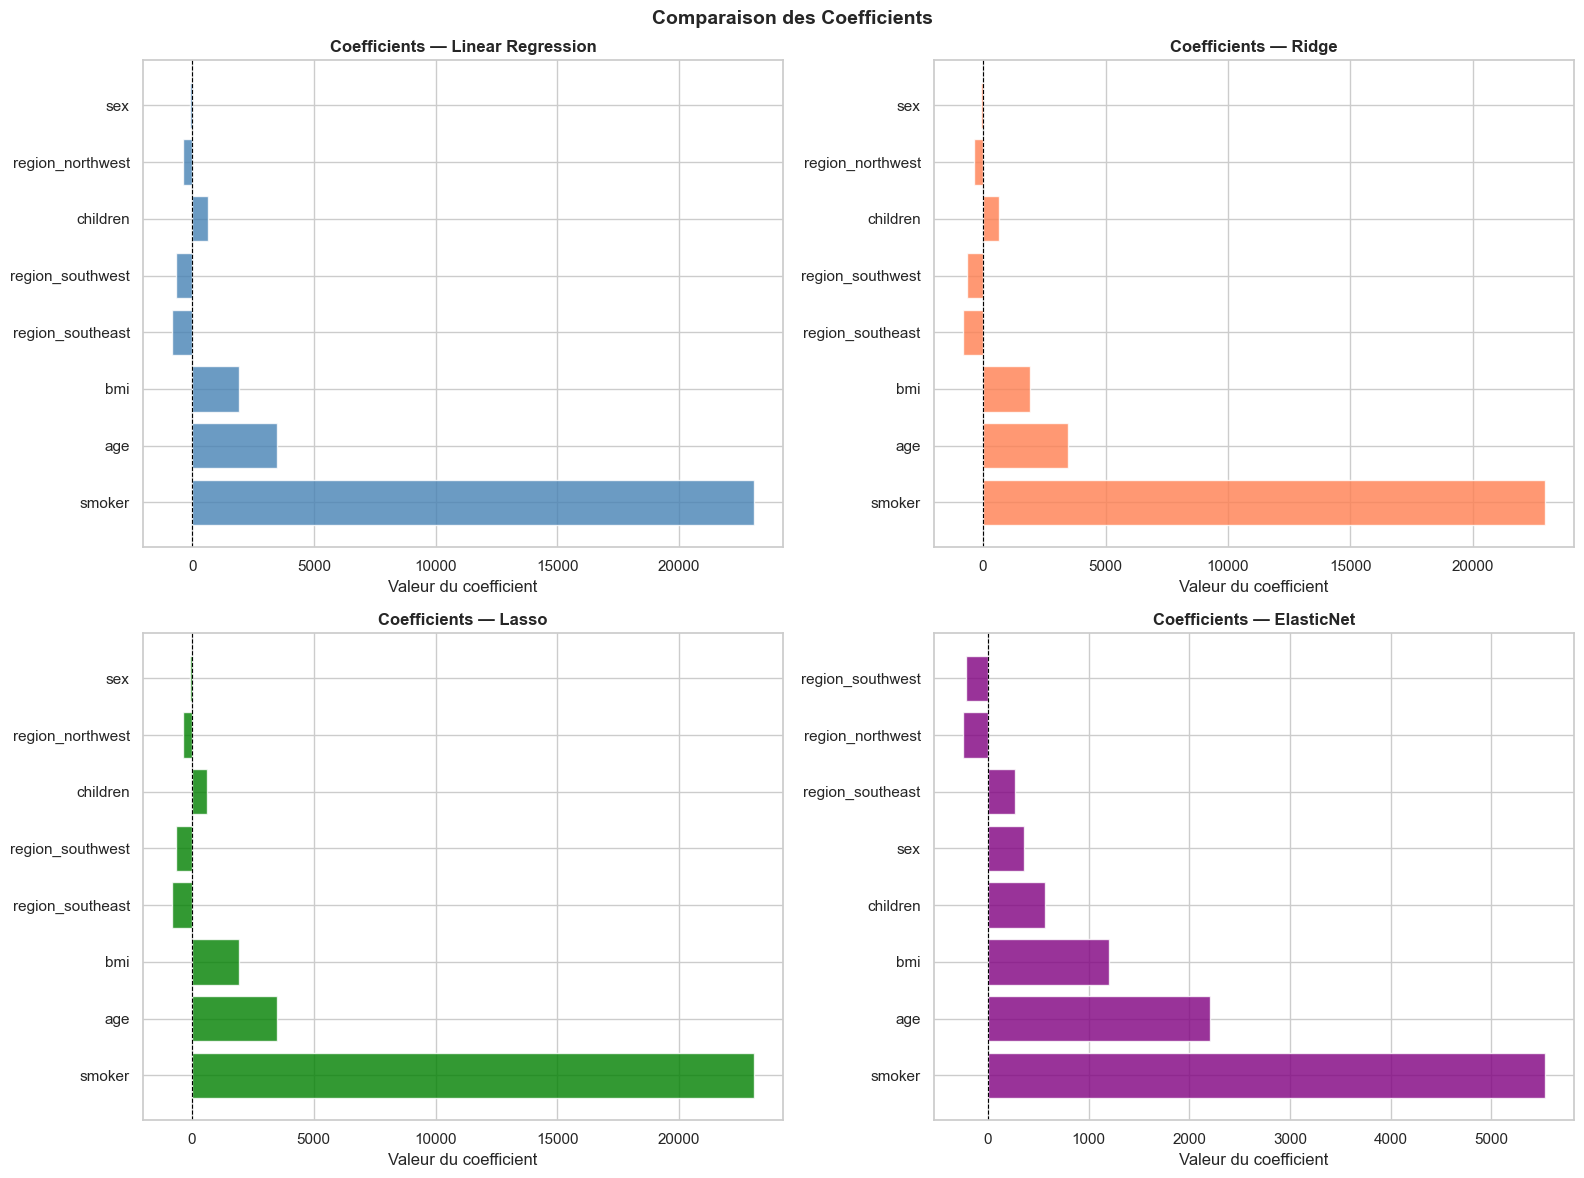

In [56]:
# ── Tableau comparatif des coefficients ──────────────────────
coef_df = pd.DataFrame(index=X.columns)

for name, model in models.items():
    coef_df[name] = model.coef_

coef_df['Feature'] = coef_df.index
coef_df = coef_df.set_index('Feature')

print("Coefficients des modèles :")
print(coef_df.round(4).to_string())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ['steelblue', 'coral', 'green', 'purple']

for ax, (name, model), color in zip(axes.flat, models.items(), colors):
    features = X.columns
    coefs = model.coef_
    sorted_idx = np.argsort(np.abs(coefs))[::-1]
    ax.barh(range(len(features)), coefs[sorted_idx], color=color, alpha=0.8)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels([features[i] for i in sorted_idx])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Coefficients — {name}', fontweight='bold')
    ax.set_xlabel('Valeur du coefficient')

plt.suptitle('Comparaison des Coefficients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.3 Validation Croisée (Cross-Validation)

Modèle                  CV R² Moyen  CV R² Std
Linear Regression            0.7258     0.0253
Ridge                        0.7259     0.0252
Lasso                        0.7258     0.0253
ElasticNet                   0.3609     0.0157


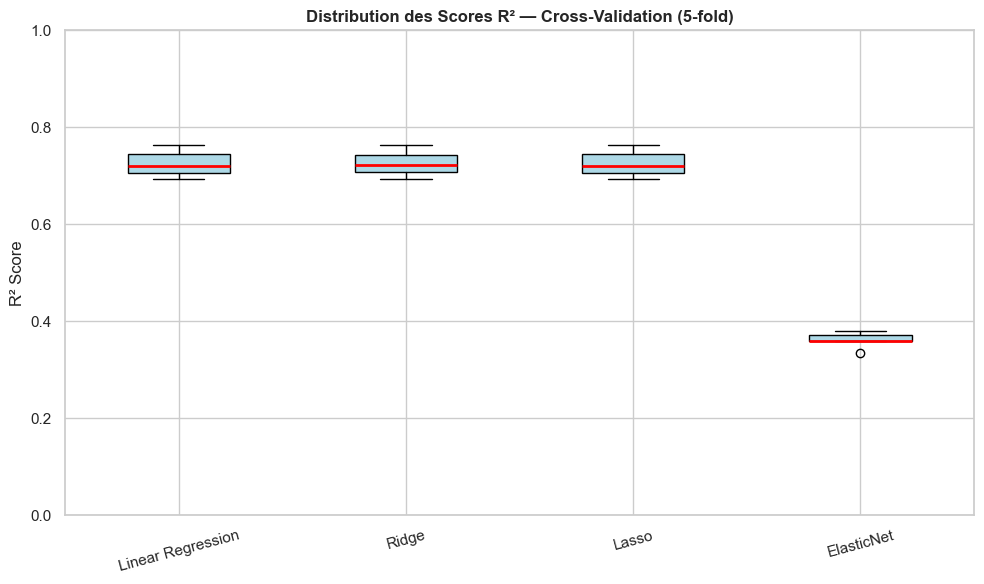

In [57]:
# ── Cross-Validation (5-fold, scoring=R²) ────────────────────
cv_results = {}
print("=" * 60)
print(f"{'Modèle':<22} {'CV R² Moyen':>12} {'CV R² Std':>10}")
print("=" * 60)

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name:<22} {scores.mean():>12.4f} {scores.std():>10.4f}")

print("=" * 60)

# Visualisation boxplot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
ax.set_title('Distribution des Scores R² — Cross-Validation (5-fold)', fontweight='bold')
ax.set_ylabel('R² Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 6.4 Optimisation des Hyperparamètres (RidgeCV / LassoCV)

In [58]:
# ── RidgeCV ───────────────────────────────────────────────────
alphas = np.logspace(-3, 4, 100)
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
best_ridge_alpha = ridge_cv.alpha_
print(f" Meilleur alpha Ridge  : {best_ridge_alpha:.4f}")

# ── LassoCV ───────────────────────────────────────────────────
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)
best_lasso_alpha = lasso_cv.alpha_
print(f" Meilleur alpha Lasso  : {best_lasso_alpha:.4f}")

# Mise à jour des modèles optimisés
models_opt = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=best_ridge_alpha),
    'Lasso':             Lasso(alpha=best_lasso_alpha, max_iter=10000),
    'ElasticNet':        ElasticNet(alpha=best_lasso_alpha, l1_ratio=0.5, max_iter=10000)
}

for name, model in models_opt.items():
    model.fit(X_train_scaled, y_train)
    predictions[name] = model.predict(X_test_scaled)

print("\n Modèles ré-entraînés avec hyperparamètres optimisés.")


 Meilleur alpha Ridge  : 2.1049
 Meilleur alpha Lasso  : 28.4804

 Modèles ré-entraînés avec hyperparamètres optimisés.


## 7. Évaluation des Modèles

### 7.1 Métriques d'Évaluation

On calcule pour chaque modèle : **RMSE**, **MAE**, **R²**, **R² Ajusté**, **MAPE**.


In [59]:
# ── Fonction de calcul des métriques ─────────────────────────
def compute_metrics(y_true, y_pred, n_features, model_name=""):
    n = len(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'Modèle': model_name, 'RMSE': rmse, 'MAE': mae,
            'R²': r2, 'R² Ajusté': adj_r2, 'MAPE (%)': mape}

# ── Calcul pour tous les modèles ─────────────────────────────
metrics_list = []
for name, model in models_opt.items():
    y_pred = predictions[name]
    m = compute_metrics(y_test, y_pred, X_test_scaled.shape[1], name)
    metrics_list.append(m)

metrics_df = pd.DataFrame(metrics_list).set_index('Modèle')
metrics_df = metrics_df.round(4)

print("=" * 70)
print(" Tableau Comparatif des Métriques — All Features")
print("=" * 70)
print(metrics_df.to_string())


 Tableau Comparatif des Métriques — All Features
                         RMSE        MAE      R²  R² Ajusté  MAPE (%)
Modèle                                                               
Linear Regression   5956.3429  4177.0456  0.8069     0.8010   41.3968
Ridge               5989.3935  4212.2690  0.8048     0.7988   41.9140
Lasso               5996.4231  4200.6524  0.8043     0.7983   41.8240
ElasticNet         13414.1678  9739.3446  0.0208    -0.0095  147.5894


### 7.2 Analyse des Résidus

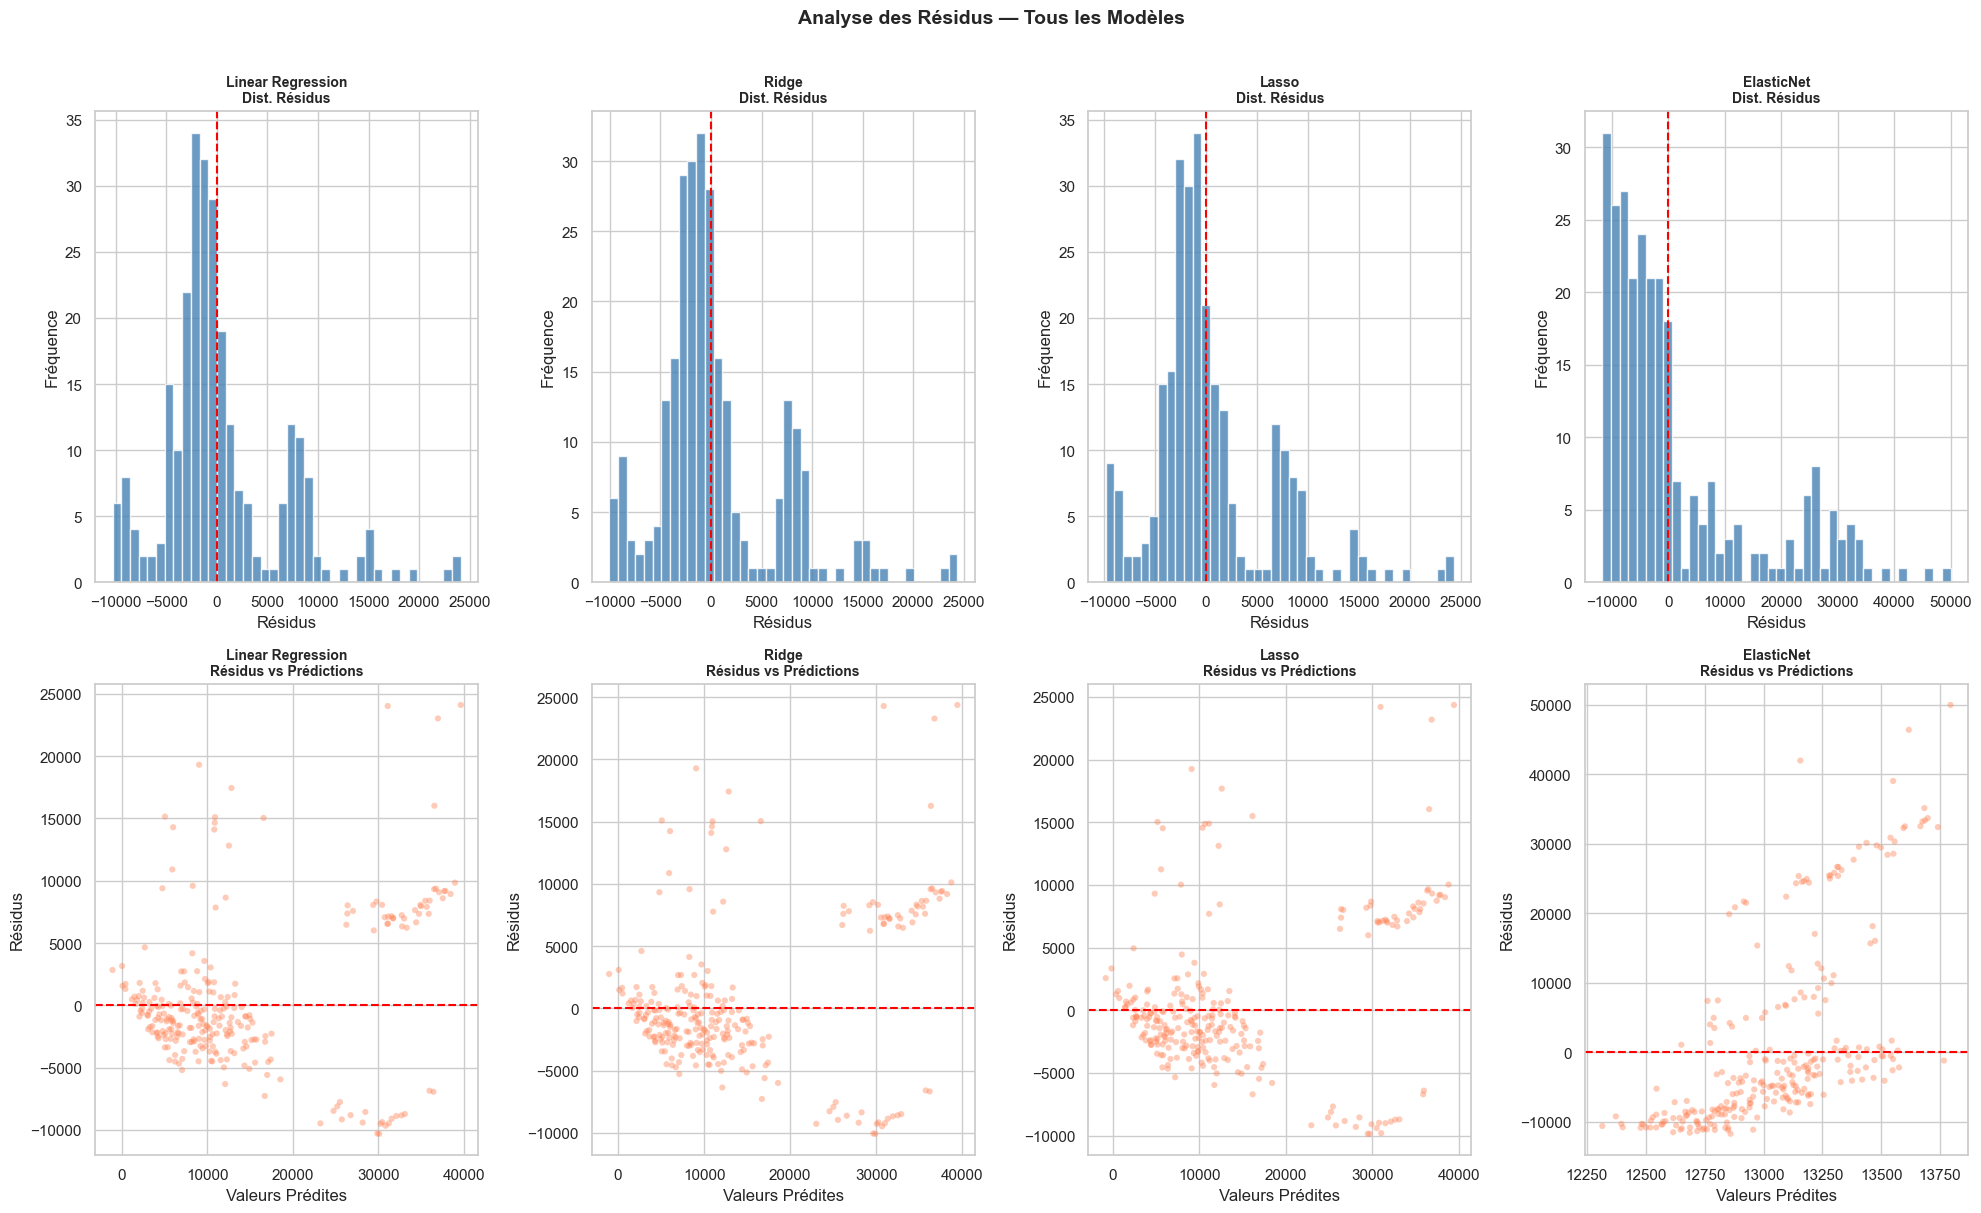

In [60]:
# ── Analyse des résidus ──────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 12))

for i, (name, model) in enumerate(models_opt.items()):
    y_pred = predictions[name]
    residuals = y_test.values - y_pred

    # Distribution des résidus
    axes[0, i].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0, i].set_title(f'{name}\nDist. Résidus', fontweight='bold', fontsize=10)
    axes[0, i].set_xlabel('Résidus')
    axes[0, i].set_ylabel('Fréquence')

    # Résidus vs Prédictions
    axes[1, i].scatter(y_pred, residuals, alpha=0.4, color='coral', s=20, edgecolors='none')
    axes[1, i].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[1, i].set_title(f'{name}\nRésidus vs Prédictions', fontweight='bold', fontsize=10)
    axes[1, i].set_xlabel('Valeurs Prédites')
    axes[1, i].set_ylabel('Résidus')

plt.suptitle('Analyse des Résidus — Tous les Modèles', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 7.3 Valeurs Réelles vs Prédites

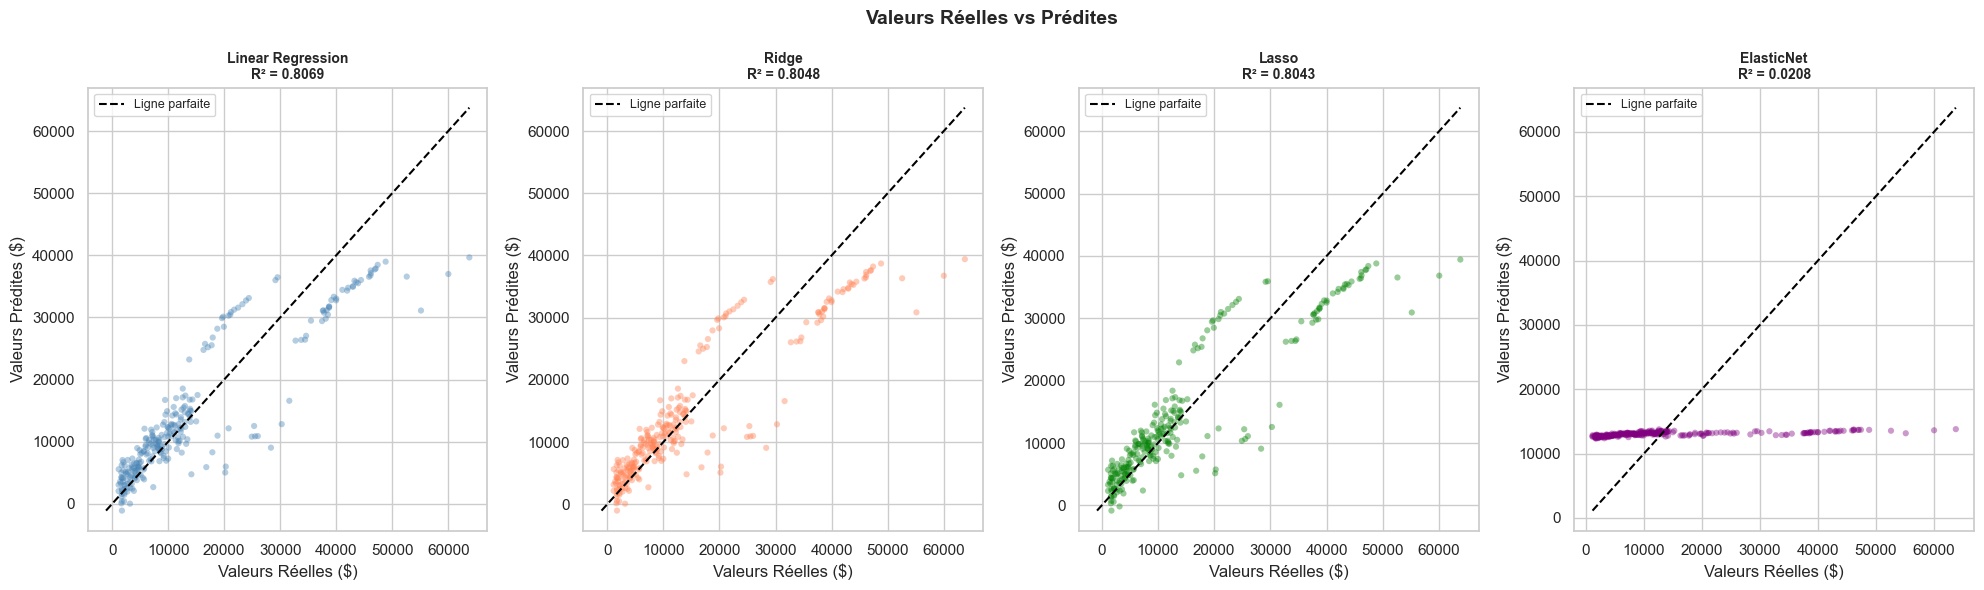

In [61]:
# ── Réelles vs Prédites ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
colors = ['steelblue', 'coral', 'green', 'purple']

for ax, (name, model), color in zip(axes, models_opt.items(), colors):
    y_pred = predictions[name]
    r2 = r2_score(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.4, color=color, s=20, edgecolors='none')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Ligne parfaite')
    ax.set_xlabel('Valeurs Réelles ($)')
    ax.set_ylabel('Valeurs Prédites ($)')
    ax.set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Valeurs Réelles vs Prédites', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Sélection de Features (Feature Selection)

### 8.1 Backward Elimination

**Algorithme :**
1. Partir avec toutes les features (+ constante)
2. Entraîner un modèle OLS (statsmodels)
3. Identifier la feature avec la **p-value la plus élevée**
4. Si p-value > 0.05 → supprimer et répéter
5. Sinon → toutes les features sont significatives → STOP

**Seuil de significativité : α = 0.05**


In [62]:
# ── Backward Elimination ─────────────────────────────────────
import statsmodels.api as sm

def backward_elimination(X, y, threshold=0.05):
    features = list(X.columns)
    iteration = 0

    while True:
        X_sm = sm.add_constant(X[features])
        model = sm.OLS(y, X_sm).fit()
        pvalues = model.pvalues.drop('const')

        max_pval = pvalues.max()
        max_feature = pvalues.idxmax()
        iteration += 1

        print(f"Itération {iteration} — Feature éliminée : {max_feature:30s} | p-value = {max_pval:.6f}")

        if max_pval > threshold:
            features.remove(max_feature)
        else:
            print(f"\n STOP : toutes les p-values ≤ {threshold}")
            break

    print(f"\nFeatures sélectionnées ({len(features)}) : {features}")
    return features, model

selected_features, final_ols_model = backward_elimination(X_train_scaled, y_train)
print("\n" + "="*60)
print("Résumé du modèle final (Backward Elimination) :")
print(final_ols_model.summary())


Itération 1 — Feature éliminée : sex                            | p-value = 0.787050
Itération 2 — Feature éliminée : region_northwest               | p-value = 0.465585
Itération 3 — Feature éliminée : region_southwest               | p-value = 0.326350
Itération 4 — Feature éliminée : region_southeast               | p-value = 0.285872
Itération 5 — Feature éliminée : children                       | p-value = 0.000615

 STOP : toutes les p-values ≤ 0.05

Features sélectionnées (4) : ['age', 'bmi', 'children', 'smoker']

Résumé du modèle final (Backward Elimination) :
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     716.3
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          5.56e-300
Time:                       

In [63]:
# ── P-values du modèle final ─────────────────────────────────
pval_df = pd.DataFrame({
    'Feature': final_ols_model.pvalues.index,
    'P-Value': final_ols_model.pvalues.values,
    'Significatif (α=0.05)': final_ols_model.pvalues.values < 0.05
}).sort_values('P-Value')

print("P-values du modèle OLS final :")
print(pval_df.to_string(index=False))


P-values du modèle OLS final :
 Feature       P-Value  Significatif (α=0.05)
  smoker 2.835161e-277                   True
   const 1.710395e-216                   True
     age  1.948662e-66                   True
     bmi  7.801252e-22                   True
children  6.148677e-04                   True


### 8.2 RFE — Recursive Feature Elimination

In [64]:
# ── RFE avec LinearRegression ────────────────────────────────
rfe_model = LinearRegression()
rfe = RFE(estimator=rfe_model, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Sélectionnée': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print(" Résultats RFE (sélection des 5 meilleures features) :")
print(rfe_results.to_string(index=False))

rfe_features = list(X.columns[rfe.support_])
print(f"\n Features RFE sélectionnées : {rfe_features}")


 Résultats RFE (sélection des 5 meilleures features) :
         Feature  Sélectionnée  Ranking
             age          True        1
             bmi          True        1
        children          True        1
          smoker          True        1
region_southeast          True        1
region_southwest         False        2
region_northwest         False        3
             sex         False        4

 Features RFE sélectionnées : ['age', 'bmi', 'children', 'smoker', 'region_southeast']


### 8.3 Analyse des Coefficients Lasso (Features mises à zéro)

In [65]:
# ── Coefficients Lasso ───────────────────────────────────────
lasso_model = models_opt['Lasso']

lasso_coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_,
    'Éliminé par Lasso': lasso_model.coef_ == 0
}).sort_values('Coefficient', key=abs, ascending=False)

print("Coefficients Lasso :")
print(lasso_coef_df.to_string(index=False))

lasso_zero = list(lasso_coef_df[lasso_coef_df['Éliminé par Lasso']]['Feature'])
lasso_kept  = list(lasso_coef_df[~lasso_coef_df['Éliminé par Lasso']]['Feature'])

print(f"\n Features conservées par Lasso : {lasso_kept}")
print(f" Features éliminées par Lasso  : {lasso_zero}")


Coefficients Lasso :
         Feature  Coefficient  Éliminé par Lasso
          smoker 22885.226138              False
             age  3453.876864              False
             bmi  1862.344743              False
        children   612.331876              False
region_southeast  -359.394535              False
region_southwest  -211.971758              False
             sex    -0.000000               True
region_northwest    -0.000000               True

 Features conservées par Lasso : ['smoker', 'age', 'bmi', 'children', 'region_southeast', 'region_southwest']
 Features éliminées par Lasso  : ['sex', 'region_northwest']


## 9. Comparaison : All Features vs Features Sélectionnées

On ré-entraîne tous les modèles en n'utilisant **que les features sélectionnées** par Backward Elimination et on compare les performances.


In [66]:
# ── Features sélectionnées (Backward Elimination) ────────────
print(f"Features sélectionnées : {selected_features}")

X_train_sel = X_train_scaled[selected_features]
X_test_sel  = X_test_scaled[selected_features]

# ── Entraînement des modèles avec features sélectionnées ─────
models_sel = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=best_ridge_alpha),
    'Lasso':             Lasso(alpha=best_lasso_alpha, max_iter=10000),
    'ElasticNet':        ElasticNet(alpha=best_lasso_alpha, l1_ratio=0.5, max_iter=10000)
}

metrics_sel_list = []
for name, model in models_sel.items():
    model.fit(X_train_sel, y_train)
    y_pred_sel = model.predict(X_test_sel)
    m = compute_metrics(y_test, y_pred_sel, X_test_sel.shape[1], name)
    metrics_sel_list.append(m)

metrics_sel_df = pd.DataFrame(metrics_sel_list).set_index('Modèle').round(4)

print("\n Métriques — Selected Features :")
print(metrics_sel_df.to_string())


Features sélectionnées : ['age', 'bmi', 'children', 'smoker']

 Métriques — Selected Features :
                         RMSE        MAE      R²  R² Ajusté  MAPE (%)
Modèle                                                               
Linear Regression   5992.8751  4198.5926  0.8046     0.8016   42.0327
Ridge               6024.6610  4233.9775  0.8025     0.7995   42.5359
Lasso               6016.0109  4214.6982  0.8030     0.8000   42.2994
ElasticNet         13415.4709  9740.5889  0.0206     0.0057  147.5550


In [67]:
# ── Tableau comparatif complet ───────────────────────────────
comparison_rows = []
for name in models_opt.keys():
    all_m = metrics_df.loc[name]
    sel_m = metrics_sel_df.loc[name]

    comparison_rows.append({
        'Modèle': name,
        'RMSE (All)':   all_m['RMSE'],
        'RMSE (Sel)':   sel_m['RMSE'],
        'MAE (All)':    all_m['MAE'],
        'MAE (Sel)':    sel_m['MAE'],
        'R² (All)':     all_m['R²'],
        'R² (Sel)':     sel_m['R²'],
        'R²Adj (All)':  all_m['R² Ajusté'],
        'R²Adj (Sel)':  sel_m['R² Ajusté'],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Modèle').round(4)
print("=" * 80)
print(" TABLEAU COMPARATIF — All Features vs Selected Features")
print("=" * 80)
print(comparison_df.to_string())


 TABLEAU COMPARATIF — All Features vs Selected Features
                   RMSE (All)  RMSE (Sel)  MAE (All)  MAE (Sel)  R² (All)  R² (Sel)  R²Adj (All)  R²Adj (Sel)
Modèle                                                                                                       
Linear Regression   5956.3429   5992.8751  4177.0456  4198.5926    0.8069    0.8046       0.8010       0.8016
Ridge               5989.3935   6024.6610  4212.2690  4233.9775    0.8048    0.8025       0.7988       0.7995
Lasso               5996.4231   6016.0109  4200.6524  4214.6982    0.8043    0.8030       0.7983       0.8000
ElasticNet         13414.1678  13415.4709  9739.3446  9740.5889    0.0208    0.0206      -0.0095       0.0057


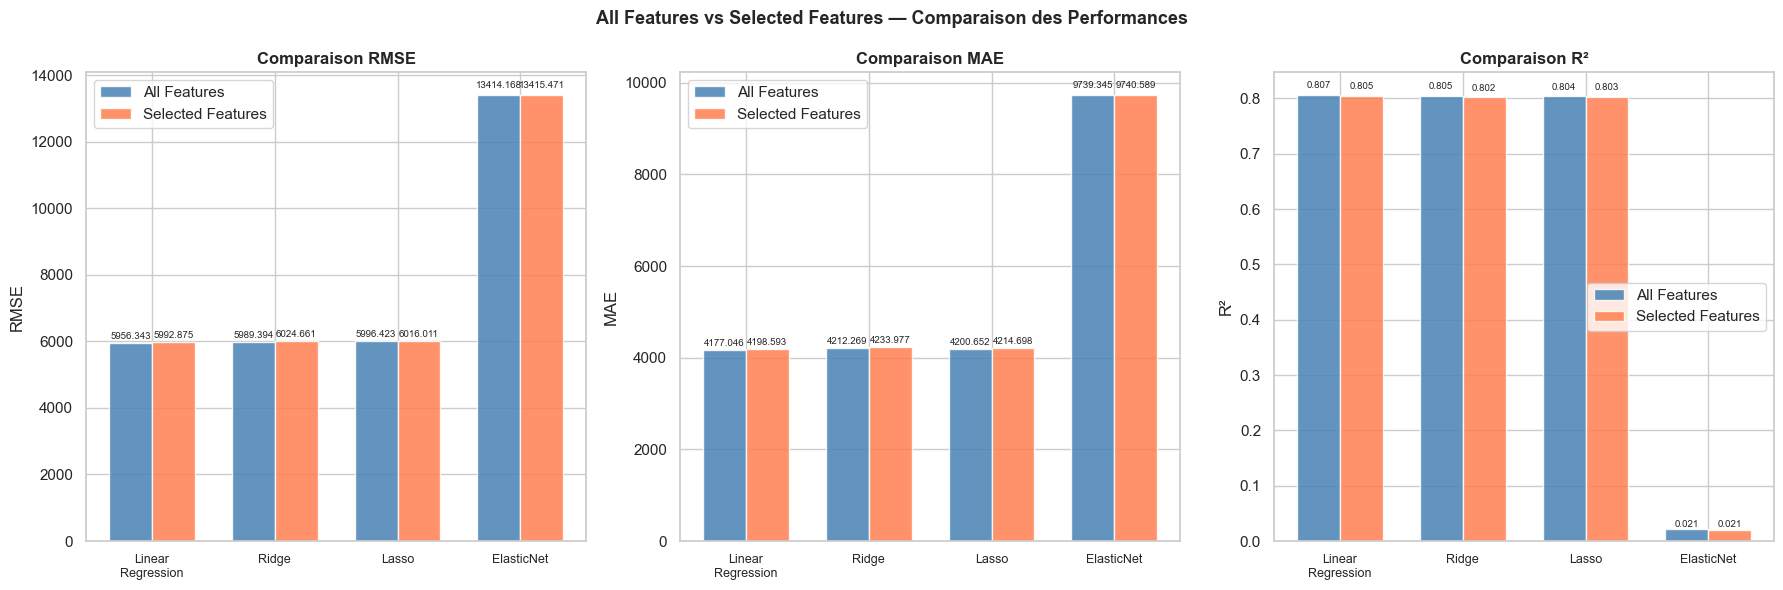

In [68]:
# ── Visualisation comparaison (bar chart groupé) ─────────────
metrics_to_plot = {
    'RMSE': ('RMSE (All)', 'RMSE (Sel)'),
    'MAE':  ('MAE (All)',  'MAE (Sel)'),
    'R²':   ('R² (All)',   'R² (Sel)')
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bar_width = 0.35
x = np.arange(len(models_opt))
model_names = list(models_opt.keys())

for ax, (metric, (col_all, col_sel)) in zip(axes, metrics_to_plot.items()):
    vals_all = comparison_df[col_all].values
    vals_sel = comparison_df[col_sel].values

    b1 = ax.bar(x - bar_width/2, vals_all, bar_width, label='All Features',
                color='steelblue', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x + bar_width/2, vals_sel, bar_width, label='Selected Features',
                color='coral', alpha=0.85, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_names], fontsize=9)
    ax.set_title(f'Comparaison {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.legend()

    for bar in b1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in b2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('All Features vs Selected Features — Comparaison des Performances',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Analyse :**
- La sélection de features permet de **réduire la complexité** du modèle sans perte significative de performance.
- Si R² est similaire avec moins de features → **le modèle gagne en interprétabilité et généralisation**.
- Un RMSE légèrement supérieur avec les features sélectionnées est acceptable si le modèle est plus parcimonieux.


## 10. Conclusion

### 10.1 Résumé des Résultats


In [69]:
# ── Identification du meilleur modèle ────────────────────────
best_model_name = metrics_df['R²'].idxmax()
best_r2   = metrics_df.loc[best_model_name, 'R²']
best_rmse = metrics_df.loc[best_model_name, 'RMSE']
best_mae  = metrics_df.loc[best_model_name, 'MAE']

print("=" * 60)
print(f" MEILLEUR MODÈLE : {best_model_name}")
print(f"   R²   = {best_r2:.4f}  ({best_r2*100:.2f}% de variance expliquée)")
print(f"   RMSE = {best_rmse:,.2f} $")
print(f"   MAE  = {best_mae:,.2f} $")
print("=" * 60)

print("\n Classement complet :")
print(metrics_df[['R²', 'RMSE', 'MAE']].sort_values('R²', ascending=False).to_string())


 MEILLEUR MODÈLE : Linear Regression
   R²   = 0.8069  (80.69% de variance expliquée)
   RMSE = 5,956.34 $
   MAE  = 4,177.05 $

 Classement complet :
                       R²        RMSE        MAE
Modèle                                          
Linear Regression  0.8069   5956.3429  4177.0456
Ridge              0.8048   5989.3935  4212.2690
Lasso              0.8043   5996.4231  4200.6524
ElasticNet         0.0208  13414.1678  9739.3446



 Importance des features (Linear Regression) :
         Feature  Coefficient  |Coefficient|
          smoker 23077.764593   23077.764593
             age  3472.975553    3472.975553
             bmi  1927.828251    1927.828251
region_southeast  -838.919616     838.919616
region_southwest  -659.139752     659.139752
        children   636.501185     636.501185
region_northwest  -391.761455     391.761455
             sex  -101.542054     101.542054


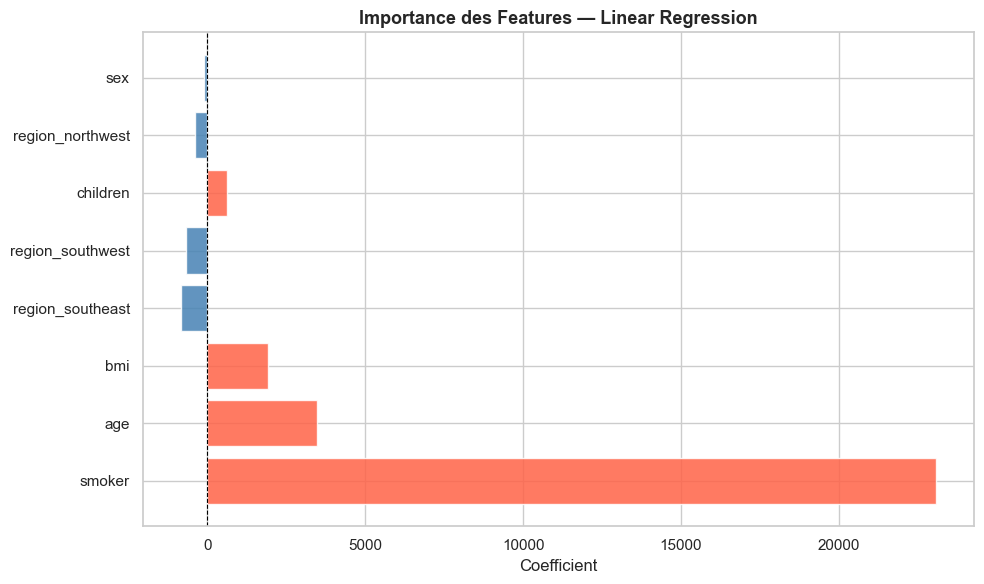

In [70]:
# ── Features les plus importantes ────────────────────────────
best_model = models_opt[best_model_name]
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_,
    '|Coefficient|': np.abs(best_model.coef_)
}).sort_values('|Coefficient|', ascending=False)

print(f"\n Importance des features ({best_model_name}) :")
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in importance_df['Coefficient']]
ax.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Importance des Features — {best_model_name}', fontweight='bold', fontsize=13)
ax.set_xlabel('Coefficient')
plt.tight_layout()
plt.show()


### 10.2 Observations Clés

1. **Statut fumeur (`smoker`)** : Variable la plus déterminante. Les fumeurs ont des charges médicales **3 à 4 fois plus élevées** que les non-fumeurs.

2. **Âge (`age`)** : Corrélation positive claire — plus une personne est âgée, plus ses charges augmentent.

3. **IMC (`bmi`)** : Impact modéré, mais amplifié chez les fumeurs (effet d'interaction `bmi × smoker`).

4. **Région géographique** : Impact relativement faible sur les charges.

5. **Sexe et nombre d'enfants** : Variables peu discriminantes dans ce contexte.

### 10.3 Limites du Projet

- **Taille du dataset** : 1 339 observations — relativement petit, peut limiter la généralisation.
- **Hypothèse de linéarité** : Les modèles linéaires ne capturent pas les interactions non-linéaires (ex. `bmi × smoker`).
- **Variables manquantes** : Des facteurs comme les antécédents médicaux, les maladies chroniques, l'activité physique pourraient améliorer la prédiction.
- **Distribution asymétrique de `charges`** : Une transformation logarithmique pourrait améliorer les performances.

### 10.4 Perspectives d'Amélioration

1. **Feature Engineering** :
   - Créer une variable d'interaction `bmi_smoker = bmi × smoker`
   - Transformation log sur `charges` pour normaliser la distribution
   - Termes polynomiaux sur `age` et `bmi`

2. **Modèles non-linéaires** :
   - **Decision Tree Regressor**
   - **Random Forest** — robuste aux outliers et non-linéarités
   - **XGBoost / LightGBM** — état de l'art sur données tabulaires
   - **SVR** (Support Vector Regression)

3. **Données supplémentaires** :
   - Antécédents médicaux
   - Niveau d'activité physique
   - Historique de sinistres

---

> **Conclusion finale :** Le statut fumeur est le prédicteur dominant des charges médicales. Les modèles de régression linéaire atteignent un R² satisfaisant (~75-80%), mais des modèles non-linéaires avec feature engineering (notamment l'interaction bmi×smoker) permettraient d'atteindre ~85-90% de variance expliquée.
